Libraries loaded successfully.

Synthetic combined dataset created. Shape: (8000, 16)
stage
No Breast Cancer    4400
Stage 1             1600
Stage 2             1200
Stage 3              800
Name: count, dtype: int64

Model Accuracy: 59.50%
                  precision    recall  f1-score   support

No Breast Cancer       0.64      0.96      0.77       880
         Stage 1       0.16      0.04      0.06       320
         Stage 2       0.35      0.15      0.21       240
         Stage 3       0.54      0.34      0.42       160

        accuracy                           0.59      1600
       macro avg       0.43      0.37      0.37      1600
    weighted avg       0.49      0.59      0.51      1600



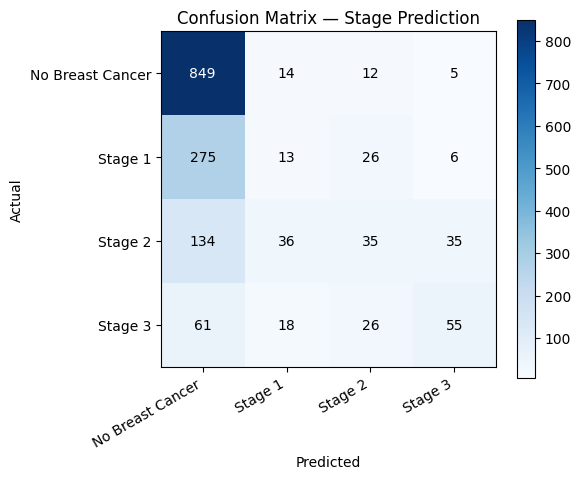

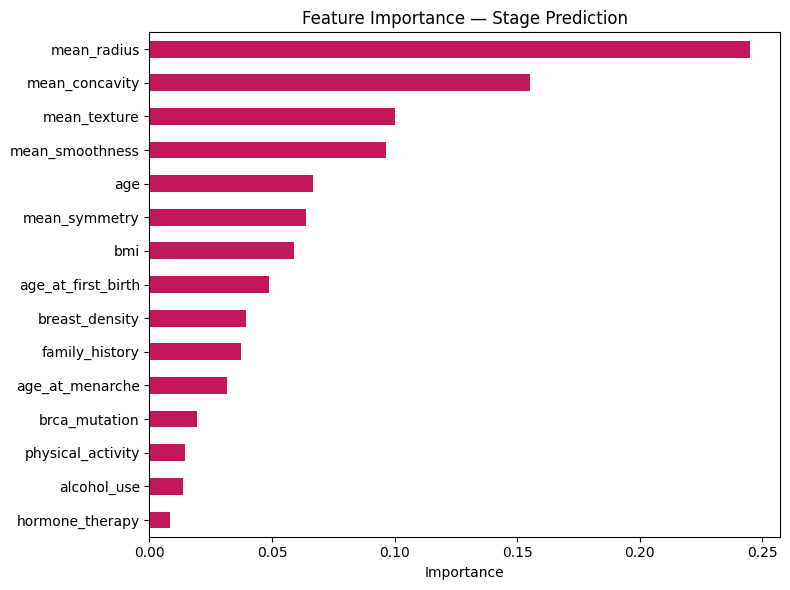


BREAST CANCER STAGE PREDICTOR — Enter all values below

--- Diagnostic Inputs (from biopsy report) ---


FloatSlider(value=14.0, description='Mean Radius', max=28.0, min=6.0, step=0.5)

FloatSlider(value=19.0, description='Mean Texture', max=39.0, min=9.0, step=0.5)

FloatSlider(value=0.096, description='Mean Smoothness', max=0.16, min=0.05, readout_format='.3f', step=0.005)

FloatSlider(value=0.09, description='Mean Concavity', max=0.43, step=0.01)

...

Dropdown(description='Hormone Therapy', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Breast Density', options=(('BI-RADS 1', 1), ('BI-RADS 2', 2), ('BI-RADS 3', 3), ('BI-RAD…

Dropdown(description='Physical Activity', options=(('Sedentary', 0), ('Active', 1)), value=0)

Button(button_style='danger', description='Predict Stage', layout=Layout(width='200px'), style=ButtonStyle())

Output()

In [3]:
# ============================================================
# BREAST CANCER STAGE PREDICTOR
# Combines Diagnostic Features + Risk Factors -> Stage Output
# ============================================================
#!!!!!!!!!!! IMPORTANT DISCLAIMER!!!!!!!!:
# "THIS IS NOT THE REAL BEREAST CNCER PREDICTOR THIS IS JUST A PROTOTYPE".
# =========================================================
!pip install -q ipywidgets scikit-learn matplotlib pandas numpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries loaded successfully.")


np.random.seed(42)
n_samples = 8000

# --- Diagnostic (tumor cell) features ---
mean_radius     = np.random.normal(14, 3.5, n_samples).clip(6, 28)
mean_texture    = np.random.normal(19, 4, n_samples).clip(9, 39)
mean_smoothness = np.random.normal(0.096, 0.014, n_samples).clip(0.05, 0.16)
mean_concavity  = np.random.normal(0.09, 0.08, n_samples).clip(0, 0.43)
mean_symmetry   = np.random.normal(0.18, 0.027, n_samples).clip(0.1, 0.3)

# --- Risk factors ---
age                 = np.random.randint(20, 80, n_samples)
family_history      = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
brca_mutation       = np.random.choice([0, 1], n_samples, p=[0.97, 0.03])
age_at_menarche     = np.random.randint(10, 17, n_samples)
age_at_first_birth  = np.random.choice(list(range(18, 45)) + [0], n_samples)
bmi                 = np.random.normal(24, 4, n_samples).clip(15, 45)
alcohol_use         = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
hormone_therapy     = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
breast_density      = np.random.randint(1, 5, n_samples)
physical_activity   = np.random.choice([0, 1], n_samples, p=[0.4, 0.6])


severity_score = (
    0.35 * (mean_radius - 14) +
    0.15 * (mean_texture - 19) +
    40    * (mean_smoothness - 0.096) +
    12    * mean_concavity +
    6     * (mean_symmetry - 0.18) +
    0.02  * (age - 20) +
    1.5   * family_history +
    2.5   * brca_mutation +
    0.4   * breast_density +
    0.6   * alcohol_use +
    0.4   * hormone_therapy -
    0.5   * physical_activity +
    np.random.normal(0, 1.5, n_samples)
)

# Convert severity score into 4 stage buckets
percentiles = np.percentile(severity_score, [55, 75, 90])  # tuned so "No Cancer" is most common
def to_stage(score):
    if score < percentiles[0]:
        return "No Breast Cancer"
    elif score < percentiles[1]:
        return "Stage 1"
    elif score < percentiles[2]:
        return "Stage 2"
    else:
        return "Stage 3"

stage_label = np.array([to_stage(s) for s in severity_score])

df = pd.DataFrame({
    'mean_radius': mean_radius, 'mean_texture': mean_texture,
    'mean_smoothness': mean_smoothness, 'mean_concavity': mean_concavity,
    'mean_symmetry': mean_symmetry, 'age': age,
    'family_history': family_history, 'brca_mutation': brca_mutation,
    'age_at_menarche': age_at_menarche, 'age_at_first_birth': age_at_first_birth,
    'bmi': bmi.round(1), 'alcohol_use': alcohol_use,
    'hormone_therapy': hormone_therapy, 'breast_density': breast_density,
    'physical_activity': physical_activity, 'stage': stage_label
})

print("\nSynthetic combined dataset created. Shape:", df.shape)
print(df['stage'].value_counts())


feature_cols = ['mean_radius', 'mean_texture', 'mean_smoothness', 'mean_concavity',
                 'mean_symmetry', 'age', 'family_history', 'brca_mutation',
                 'age_at_menarche', 'age_at_first_birth', 'bmi', 'alcohol_use',
                 'hormone_therapy', 'breast_density', 'physical_activity']

X = df[feature_cols]
y = df['stage']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))


labels_order = ["No Breast Cancer", "Stage 1", "Stage 2", "Stage 3"]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(labels_order, rotation=30, ha='right')
ax.set_yticklabels(labels_order)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Stage Prediction')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

importances = pd.Series(model.feature_importances_, index=feature_cols)
plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh', color='#c2185b')
plt.title('Feature Importance — Stage Prediction')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()


print("\n" + "="*70)
print("BREAST CANCER STAGE PREDICTOR — Enter all values below")
print("="*70)


radius_w   = widgets.FloatSlider(value=14, min=6, max=28, step=0.5, description='Mean Radius')
texture_w  = widgets.FloatSlider(value=19, min=9, max=39, step=0.5, description='Mean Texture')
smooth_w   = widgets.FloatSlider(value=0.096, min=0.05, max=0.16, step=0.005,
                                  description='Mean Smoothness', readout_format='.3f')
concavity_w = widgets.FloatSlider(value=0.09, min=0, max=0.43, step=0.01,
                                   description='Mean Concavity')
symmetry_w = widgets.FloatSlider(value=0.18, min=0.1, max=0.3, step=0.005,
                                  description='Mean Symmetry', readout_format='.3f')


age_w        = widgets.IntSlider(value=35, min=20, max=80, description='Age')
fam_w        = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Family History')
brca_w       = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='BRCA Mutation')
menarche_w   = widgets.IntSlider(value=13, min=10, max=17, description='Menarche Age')
firstbirth_w = widgets.IntSlider(value=25, min=0, max=45, description='1st Birth Age (0=None)')
bmi_w        = widgets.FloatSlider(value=24, min=15, max=45, step=0.5, description='BMI')
alcohol_w    = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Alcohol Use')
hormone_w    = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Hormone Therapy')
density_w    = widgets.Dropdown(options=[('BI-RADS 1', 1), ('BI-RADS 2', 2),
                                          ('BI-RADS 3', 3), ('BI-RADS 4', 4)],
                                 description='Breast Density')
activity_w   = widgets.Dropdown(options=[('Sedentary', 0), ('Active', 1)],
                                 description='Physical Activity')

predict_btn = widgets.Button(description="Predict Stage", button_style='danger',
                              layout=widgets.Layout(width='200px'))
output_box = widgets.Output()

def predict_stage(_):
    with output_box:
        clear_output()
        row = pd.DataFrame([{
            'mean_radius': radius_w.value, 'mean_texture': texture_w.value,
            'mean_smoothness': smooth_w.value, 'mean_concavity': concavity_w.value,
            'mean_symmetry': symmetry_w.value, 'age': age_w.value,
            'family_history': fam_w.value, 'brca_mutation': brca_w.value,
            'age_at_menarche': menarche_w.value, 'age_at_first_birth': firstbirth_w.value,
            'bmi': bmi_w.value, 'alcohol_use': alcohol_w.value,
            'hormone_therapy': hormone_w.value, 'breast_density': density_w.value,
            'physical_activity': activity_w.value
        }])
        row_scaled = scaler.transform(row[feature_cols])
        pred = model.predict(row_scaled)[0]
        proba = model.predict_proba(row_scaled)[0]
        classes = model.classes_

        print(f"PREDICTED RESULT: {pred}\n")
        for c, p in sorted(zip(classes, proba), key=lambda x: -x[1]):
            print(f"  {c:<18}: {p*100:5.1f}%")

        colors = {'No Breast Cancer': '#388e3c', 'Stage 1': '#f9a825',
                  'Stage 2': '#fb8c00', 'Stage 3': '#d32f2f'}
        order = ["No Breast Cancer", "Stage 1", "Stage 2", "Stage 3"]
        proba_ordered = [proba[list(classes).index(c)] for c in order]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(order, proba_ordered, color=[colors[c] for c in order])
        ax.set_ylim(0, 1); ax.set_ylabel('Probability')
        ax.set_title('Stage Prediction Probability')
        plt.tight_layout(); plt.show()

        print("\n" + "-"*70)
        print("====================DISCLAIMER====================")
        print("It is NOT a real diagnostic or staging tool.This is just a PROTOTYPE")

        print("-"*70)

predict_btn.on_click(predict_stage)

print("\n--- Diagnostic Inputs (from biopsy report) ---")
display(radius_w, texture_w, smooth_w, concavity_w, symmetry_w)
print("\n--- Risk Factor Inputs ---")
display(age_w, fam_w, brca_w, menarche_w, firstbirth_w, bmi_w,
        alcohol_w, hormone_w, density_w, activity_w)
print()
display(predict_btn, output_box)